In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Cargar dataset
df = pd.read_csv("laptop_pricing_dataset_mod1.csv")

# Información preliminar
print(df.head())
print(df.info())
print(df.describe())

   Unnamed: 0 Manufacturer  Category     Screen  GPU  OS  CPU_core  \
0           0         Acer         4  IPS Panel    2   1         5   
1           1         Dell         3    Full HD    1   1         3   
2           2         Dell         3    Full HD    1   1         7   
3           3         Dell         4  IPS Panel    2   1         5   
4           4           HP         4    Full HD    2   1         7   

   Screen_Size_cm  CPU_frequency  RAM_GB  Storage_GB_SSD  Weight_kg  Price  
0          35.560            1.6       8             256       1.60    978  
1          39.624            2.0       4             256       2.20    634  
2          39.624            2.7       8             256       2.20    946  
3          33.782            1.6       8             128       1.22   1244  
4          39.624            1.8       8             256       1.91    837  
<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 13 columns):
 #   Column          No

In [6]:
df.replace("?", np.nan, inplace=True)

# Verificar valores faltantes
print(df.isnull().sum())

Unnamed: 0        0
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    4
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         5
Price             0
dtype: int64


In [7]:
promedio_peso = df["Weight_kg"].astype(float).mean()

df["Weight_kg"].replace(np.nan, promedio_peso, inplace=True)

print(df["Weight_kg"].isnull().sum())

5


C:\Users\rgabr\AppData\Local\Temp\ipykernel_50140\1793149323.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Weight_kg"].replace(np.nan, promedio_peso, inplace=True)


In [8]:
moda_pantalla = df["Screen_Size_cm"].mode()[0]

df["Screen_Size_cm"].replace(np.nan, moda_pantalla, inplace=True)

print(df["Screen_Size_cm"].isnull().sum())

4


C:\Users\rgabr\AppData\Local\Temp\ipykernel_50140\770076868.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Screen_Size_cm"].replace(np.nan, moda_pantalla, inplace=True)


In [9]:
df["Weight_kg"] = df["Weight_kg"].astype(float)

df["Screen_Size_cm"] = df["Screen_Size_cm"].astype(float)

print(df.dtypes)

Unnamed: 0          int64
Manufacturer          str
Category            int64
Screen                str
GPU                 int64
OS                  int64
CPU_core            int64
Screen_Size_cm    float64
CPU_frequency     float64
RAM_GB              int64
Storage_GB_SSD      int64
Weight_kg         float64
Price               int64
dtype: object


In [10]:
print(df.columns.tolist())

['Unnamed: 0', 'Manufacturer', 'Category', 'Screen', 'GPU', 'OS', 'CPU_core', 'Screen_Size_cm', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'Weight_kg', 'Price']


In [11]:
df["Weight_lb"] = df["Weight_kg"] * 2.205

df.drop("Weight_kg", axis=1, inplace=True)

In [12]:
df["CPU_frequency"] = (
    df["CPU_frequency"] /
    df["CPU_frequency"].max()
)

print(df["CPU_frequency"].head())

0    0.551724
1    0.689655
2    0.931034
3    0.551724
4    0.620690
Name: CPU_frequency, dtype: float64


In [13]:
bins = np.linspace(
    df["Price"].min(),
    df["Price"].max(),
    4
)

group_names = ["Bajo", "Medio", "Alto"]

df["Price_Binning"] = pd.cut(
    df["Price"],
    bins,
    labels=group_names,
    include_lowest=True
)

print(df[["Price", "Price_Binning"]].head())

   Price Price_Binning
0    978          Bajo
1    634          Bajo
2    946          Bajo
3   1244          Bajo
4    837          Bajo


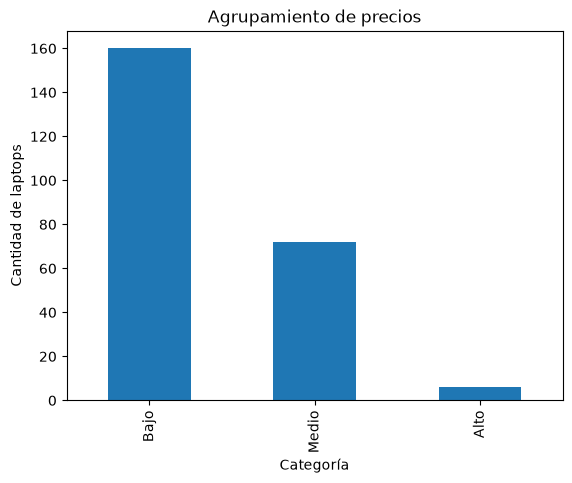

In [14]:
df["Price_Binning"].value_counts().plot(
    kind="bar"
)

plt.title("Agrupamiento de precios")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de laptops")
plt.show()

In [15]:
dummy_variable = pd.get_dummies(
    df["Screen"],
    prefix="Screen"
)

df = pd.concat(
    [df, dummy_variable],
    axis=1
)

df.drop("Screen", axis=1, inplace=True)

print(df.head())

   Unnamed: 0 Manufacturer  Category  GPU  OS  CPU_core  Screen_Size_cm  \
0           0         Acer         4    2   1         5          35.560   
1           1         Dell         3    1   1         3          39.624   
2           2         Dell         3    1   1         7          39.624   
3           3         Dell         4    2   1         5          33.782   
4           4           HP         4    2   1         7          39.624   

   CPU_frequency  RAM_GB  Storage_GB_SSD  Price  Weight_lb Price_Binning  \
0       0.551724       8             256    978    3.52800          Bajo   
1       0.689655       4             256    634    4.85100          Bajo   
2       0.931034       8             256    946    4.85100          Bajo   
3       0.551724       8             128   1244    2.69010          Bajo   
4       0.620690       8             256    837    4.21155          Bajo   

   Screen_Full HD  Screen_IPS Panel  
0           False              True  
1            Tru

In [16]:
df.to_csv(
    "laptop_pricing_dataset_limpio.csv",
    index=False
)

In [17]:
print(df.info())
print(df.head())
print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Unnamed: 0        238 non-null    int64   
 1   Manufacturer      238 non-null    str     
 2   Category          238 non-null    int64   
 3   GPU               238 non-null    int64   
 4   OS                238 non-null    int64   
 5   CPU_core          238 non-null    int64   
 6   Screen_Size_cm    234 non-null    float64 
 7   CPU_frequency     238 non-null    float64 
 8   RAM_GB            238 non-null    int64   
 9   Storage_GB_SSD    238 non-null    int64   
 10  Price             238 non-null    int64   
 11  Weight_lb         233 non-null    float64 
 12  Price_Binning     238 non-null    category
 13  Screen_Full HD    238 non-null    bool    
 14  Screen_IPS Panel  238 non-null    bool    
dtypes: bool(2), category(1), float64(3), int64(8), str(1)
memory usage: 23.3 KB
None
   U